## Trabajo Práctico 2 - Tecnología Digital VI: Machine Learning
 
**Integrantes:** Lourdes Moreira, Juana Arslanian y Matías Cerdeira  

**Fecha de entrega:** 24 de septiembre de 2026

## Introducción

En este trabajo desarrollamos un problema de clasificación multiclase utilizando datos de Spotify. El objetivo es predecir el género musical de una canción a partir de características como `danceability`, `energy`, `tempo`, `acousticness` y otras variables acústicas.

La métrica oficial de la competencia de Kaggle es **F1-Score Macro**, que calcula el F1 de cada género y luego los promedia dando el mismo peso a todas las clases.

Además, analizamos **MAP@3**, una métrica más relacionada con un sistema de recomendación, donde resulta útil que el género correcto aparezca entre las tres primeras alternativas y no necesariamente únicamente en la primera posición.

## 1. Análisis Exploratorio de Datos (EDA)

Comenzamos cargando los conjuntos de entrenamiento y test para observar su tamaño, sus columnas y las primeras filas.

In [31]:
import pandas as pd

# Cargar los datos

df = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Filas y columnas de Train:", df.shape)
print("Filas y columnas de Test:", test.shape)

display(df.head())

Filas y columnas de Train: (4200, 17)
Filas y columnas de Test: (1800, 16)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


Revisamos los tipos de variables, los valores faltantes y la cantidad de valores distintos de cada columna.

In [32]:
resumen = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "valores_distintos": df.nunique()
})

display(resumen)

,tipo,nulos,valores_distintos
popularity,int64,0,93
duration_ms,int64,0,3147
explicit,bool,0,2
danceability,float64,0,737
energy,float64,0,1129
key,int64,0,12
loudness,float64,0,3005
mode,int64,0,2
speechiness,float64,0,849
acousticness,float64,0,1508


No encontramos valores faltantes, por lo que no es necesario aplicar una estrategia de imputación.

La variable `Expected` es nuestro target y representa el género musical. La columna `Id`, en cambio, funciona solamente como identificador de cada observación y no representa una característica musical, por lo que no la utilizaremos para entrenar los modelos.

### Distribución de los géneros

Analizamos cuántas observaciones existen de cada género para determinar si el problema está balanceado.

In [33]:
balance = df["Expected"].value_counts().to_frame("cantidad")

balance["porcentaje"] = (
    balance["cantidad"] / len(df) * 100
).round(2)

display(balance)

,cantidad,porcentaje
Expected,,
jazz,700,16.67
electronic,700,16.67
hip-hop,700,16.67
acoustic,700,16.67
rock,700,16.67
classical,700,16.67


El dataset contiene seis géneros y cada uno posee exactamente 700 observaciones, es decir, aproximadamente el 16,67% del conjunto. Por lo tanto, las clases están perfectamente balanceadas.

Esto resulta conveniente porque ninguna clase domina al resto. De todas formas, utilizaremos F1-Macro porque es la métrica oficial de la competencia y permite evaluar el desempeño en todos los géneros por igual.

### Observaciones repetidas

También revisamos si existen canciones con las mismas características acústicas.

In [35]:
sin_id = df.drop(columns="Id")

caracteristicas = df.drop(
    columns=["Expected", "Id"]
)

print(
    "Repeticiones con mismas características y género:",
    sin_id.duplicated().sum()
)

print(
    "Repeticiones considerando solamente características:",
    caracteristicas.duplicated().sum()
)

generos_por_grupo = sin_id.groupby(
    list(caracteristicas.columns)
)["Expected"].nunique()

print(
    "Grupos con mismas características pero distinto género:",
    (generos_por_grupo > 1).sum()
)

Repeticiones con mismas características y género: 663
Repeticiones considerando solamente características: 680
Grupos con mismas características pero distinto género: 17


Encontramos 680 repeticiones si observamos solamente las características y 663 si además exigimos que coincida el género. También existen 17 grupos de características idénticas asociados a más de un género.

Por este motivo no eliminamos automáticamente los duplicados: dos observaciones acústicamente iguales pueden tener etiquetas diferentes y borrar una de ellas podría eliminar información válida. Sin embargo, la presencia de repeticiones es una limitación a considerar porque puede hacer que una validación aleatoria resulte algo optimista si observaciones muy similares aparecen en distintos folds.

### Resumen de las variables numéricas

In [36]:
numericas_eda = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

display(
    df[numericas_eda]
    .describe()
    .T
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max
popularity,4200.0,28.380,27.610,0.000,0.000,28.000,55.000,92.000
duration_ms,4200.0,216627.249,109043.307,17453.000,165986.750,203880.000,247040.000,2646866.000
danceability,4200.0,0.560,0.173,0.000,0.443,0.571,0.689,0.959
energy,4200.0,0.506,0.271,0.001,0.278,0.529,0.737,0.997
loudness,4200.0,-10.191,6.446,-41.531,-12.472,-8.187,-5.773,-0.927
speechiness,4200.0,0.068,0.072,0.000,0.034,0.043,0.065,0.905
acousticness,4200.0,0.463,0.376,0.000,0.075,0.417,0.853,0.996
instrumentalness,4200.0,0.170,0.326,0.000,0.000,0.000,0.075,0.978
liveness,4200.0,0.175,0.136,0.018,0.098,0.121,0.209,0.962
valence,4200.0,0.460,0.249,0.000,0.250,0.446,0.650,0.980


### ¿Qué características diferencian mejor a los géneros?

Comparamos gráficamente algunas de las variables que muestran diferencias claras entre los géneros.

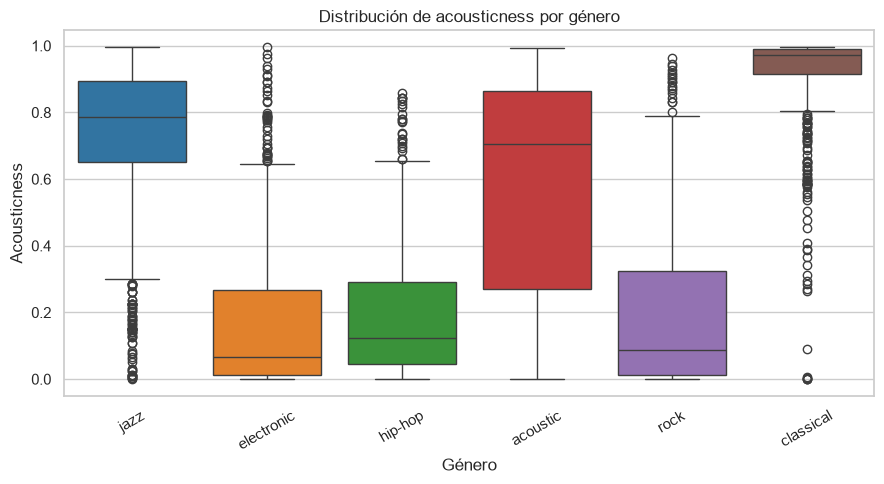

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Expected",
    y="acousticness",
    hue="Expected",
    palette="tab10",
    legend=False
)

plt.title("Distribución de acousticness por género")
plt.xlabel("Género")
plt.ylabel("Acousticness")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

`acousticness` muestra una separación importante entre los géneros. Classical, jazz y acoustic presentan valores generalmente altos, mientras que electronic, hip-hop y rock tienden a presentar valores mucho menores.

Sin embargo, todavía existe superposición entre las distribuciones, por lo que esta variable por sí sola no es suficiente para identificar un género.

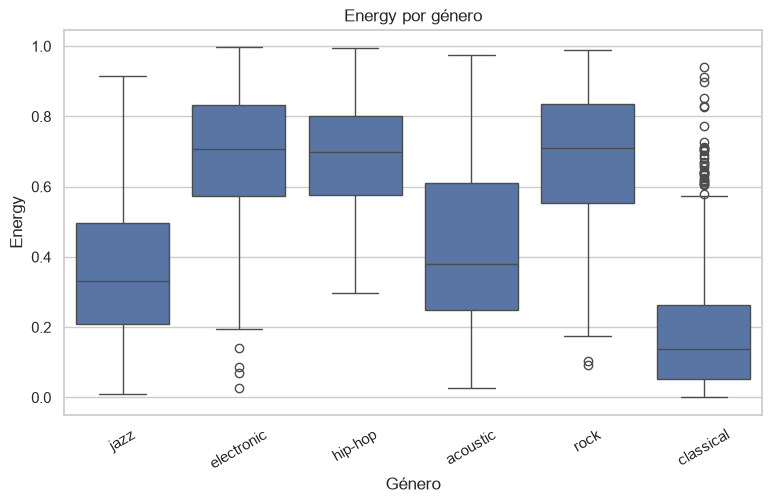

In [38]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Expected",
    y="energy"
)

plt.title("Energy por género")
plt.xlabel("Género")
plt.ylabel("Energy")
plt.xticks(rotation=30)
plt.show()

En `energy` aparece prácticamente el patrón inverso. Electronic, hip-hop y rock presentan niveles de energía mayores, mientras que classical, jazz y acoustic tienden a ser menos energéticos.

Por lo tanto, combinar `energy` con `acousticness` puede ser útil para separar distintos grupos de géneros.

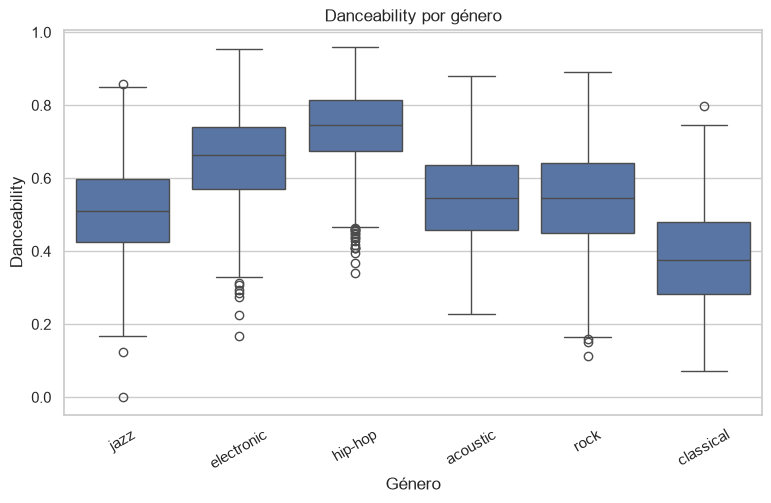

In [39]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Expected",
    y="danceability"
)

plt.title("Danceability por género")
plt.xlabel("Género")
plt.ylabel("Danceability")
plt.xticks(rotation=30)
plt.show()

`danceability` también aporta información. Hip-hop y electronic presentan valores generalmente mayores, mientras que classical tiene valores más bajos.

A partir del EDA observamos que no existe una única característica capaz de determinar el género. Variables como `acousticness`, `energy`, `loudness` y `danceability` muestran diferencias claras, pero las clases se superponen. Por eso resulta conveniente utilizar un modelo que combine varias características al mismo tiempo.

In [40]:
medianas = df.groupby("Expected")[
    [
        "acousticness",
        "energy",
        "loudness",
        "instrumentalness",
        "danceability",
        "speechiness"
    ]
].median()

display(medianas.round(3))

,acousticness,energy,loudness,instrumentalness,danceability,speechiness
Expected,,,,,,
acoustic,0.706,0.380,-9.202,0.000,0.546,0.035
classical,0.972,0.139,-20.524,0.858,0.377,0.042
electronic,0.065,0.706,-6.744,0.011,0.663,0.049
hip-hop,0.124,0.698,-5.894,0.000,0.746,0.095
jazz,0.787,0.332,-10.771,0.000,0.510,0.039
rock,0.086,0.710,-6.084,0.000,0.546,0.038


Podemos ver que muchas filas tienen las mismas características: hay 663 repeticiones con el mismo género y 680 sin considerar el género, contando las apariciones adicionales a la primera. Además, existen 17 grupos de características idénticas asociados a géneros distintos. Por lo tanto, no todas las repeticiones tienen etiquetas diferentes.


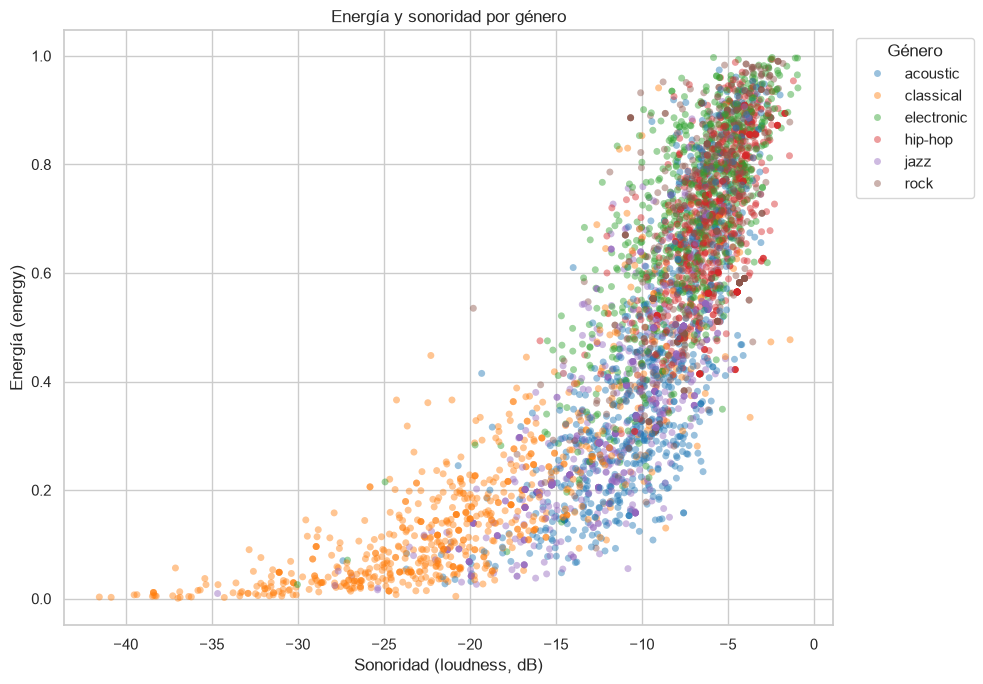

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
generos = sorted(df_etiquetado["Expected"].unique())

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_etiquetado, x="loudness", y="energy",
                hue="Expected", hue_order=generos, palette="tab10",
                alpha=0.45, s=25, linewidth=0)
plt.title("Energía y sonoridad por género")
plt.xlabel("Sonoridad (loudness, dB)")
plt.ylabel("Energía (energy)")
plt.legend(title="Género", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


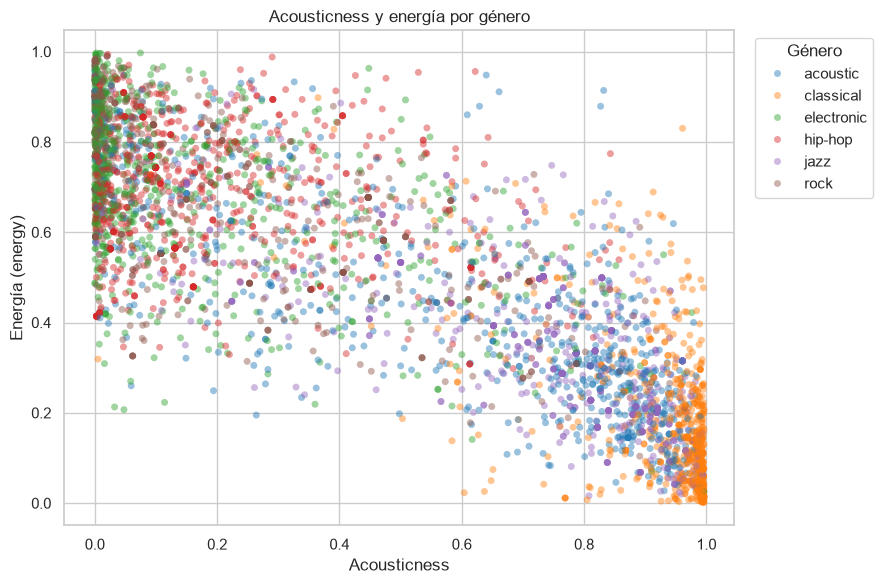

In [42]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_etiquetado, x="acousticness", y="energy",
                hue="Expected", hue_order=generos, palette="tab10",
                alpha=0.45, s=25, linewidth=0)
plt.title("Acousticness y energía por género")
plt.xlabel("Acousticness")
plt.ylabel("Energía (energy)")
plt.legend(title="Género", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


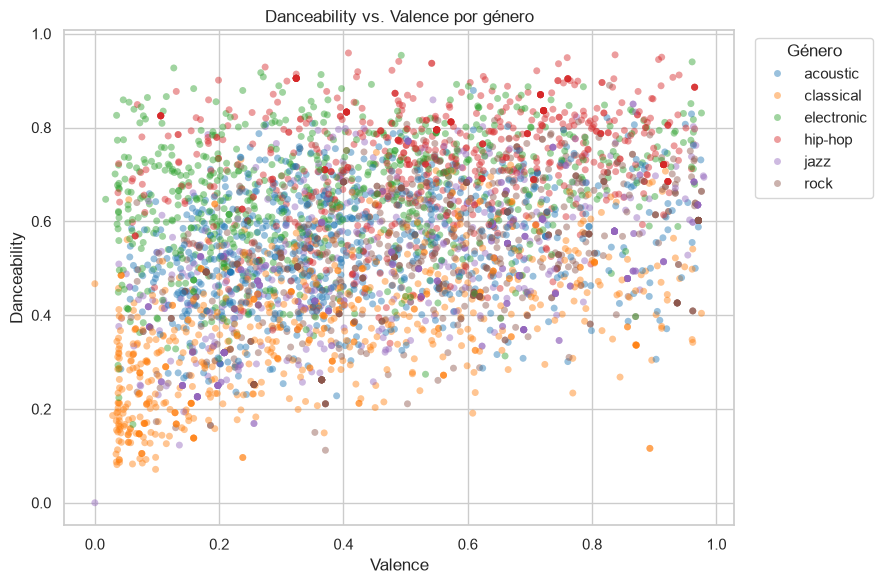

In [43]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_etiquetado, x="valence", y="danceability",
                hue="Expected", hue_order=generos, palette="tab10",
                alpha=0.45, s=25, linewidth=0)
plt.title("Danceability vs. Valence por género")
plt.xlabel("Valence")
plt.ylabel("Danceability")
plt.legend(title="Género", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Se observa que ``acousticness`` diferencia parcialmente los géneros. jazz, acoustic y classical presentan valores generalmente altos, mientras que electronic, hip-hop y rock muestran medianas mucho menores. Sin embargo, existe superposición entre las distribuciones, especialmente en acoustic, por lo que esta característica no permite clasificar los géneros por sí sola. Los puntos fuera de los bigotes representan valores atípicos, pero no necesariamente datos incorrectos.

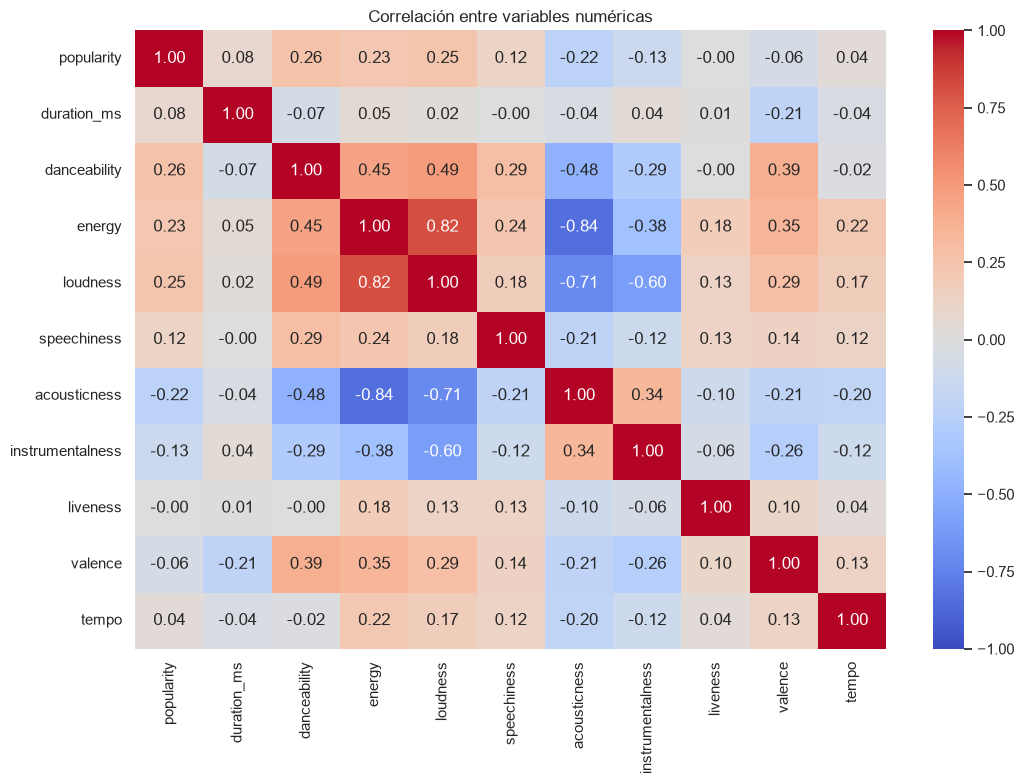

In [44]:
plt.figure(figsize=(11, 8))

correlacion = df_etiquetado[numericas].corr()

sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

## 2. Preprocesamiento de los datos

Separamos la variable objetivo `Expected` de las características utilizadas para predecir.

Eliminamos `Id` porque funciona como identificador y no representa una propiedad musical de la canción.

Consideramos `explicit`, `key`, `mode` y `time_signature` como variables categóricas. Aunque algunas estén almacenadas como números, esos valores representan categorías y no cantidades continuas.

Para las variables numéricas utilizamos `StandardScaler`, mientras que las categóricas se transforman mediante `OneHotEncoder`.

Realizamos estas transformaciones dentro de un `Pipeline` para evitar data leakage durante la validación cruzada.

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(
    columns=["Expected", "Id"]
)

y = df["Expected"]

categoricas = [
    "explicit",
    "key",
    "mode",
    "time_signature"
]

numericas = [
    columna
    for columna in X.columns
    if columna not in categoricas
]

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numericas
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categoricas
        )
    ]
)

Reservamos el 20% del dataset como conjunto de validación local. Utilizamos `stratify=y` para mantener la misma proporción de géneros en entrenamiento y validación.

Este conjunto de validación se mantiene separado de la búsqueda de modelos y de hiperparámetros para poder utilizarlo posteriormente como una evaluación final local.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)

Entrenamiento: (3360, 15)
Validación: (840, 15)


## 3. Modelos de Machine Learning

Probamos dos modelos diferentes.

El primero es una **Regresión Logística**, que sirve como modelo relativamente simple y permite establecer un resultado base.

El segundo es un **Random Forest**, que combina múltiples árboles de decisión y puede capturar relaciones no lineales e interacciones entre las características.

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_logistico = Pipeline(
    steps=[
        (
            "pre",
            preprocesador
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

modelo_rf = Pipeline(
    steps=[
        (
            "pre",
            preprocesador
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

## 4. Model Selection con validación cruzada

Para comparar los modelos de manera más robusta no dependemos únicamente de una sola división entre entrenamiento y validación.

Utilizamos **Stratified K-Fold Cross Validation con 5 folds**. En cada iteración el modelo se entrena con cuatro partes de los datos y se evalúa con la restante.

La versión estratificada mantiene aproximadamente la misma proporción de géneros en cada fold.

La métrica utilizada para seleccionar el modelo es `F1-Macro`, ya que es la métrica oficial de Kaggle.

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = []

for nombre, modelo in [
    ("Regresión Logística", modelo_logistico),
    ("Random Forest", modelo_rf)
]:
    
    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )
    
    resultados_cv.append({
        "Modelo": nombre,
        "F1-Macro promedio": scores.mean(),
        "Desvío": scores.std()
    })

resultados_cv = pd.DataFrame(
    resultados_cv
)

display(
    resultados_cv.round(3)
)

,Modelo,F1-Macro promedio,Desvío
0,Regresión Logística,0.643,0.019
1,Random Forest,0.808,0.011


Random Forest obtiene un F1-Macro promedio considerablemente mayor que la Regresión Logística y además presenta poca variación entre folds.

Por este motivo lo seleccionamos como el modelo principal para continuar con la búsqueda de hiperparámetros.

## 5. Búsqueda de hiperparámetros

Hasta ahora utilizamos Random Forest con parámetros elegidos inicialmente. Para buscar una configuración mejor utilizamos `GridSearchCV`.

Probamos distintas cantidades de árboles (`n_estimators`) y distintas profundidades máximas (`max_depth`).

La búsqueda vuelve a utilizar validación cruzada y selecciona los parámetros que obtienen el mayor `F1-Macro`.

In [49]:
from sklearn.model_selection import GridSearchCV

parametros_f1 = {
    "model__n_estimators": [
        100,
        200
    ],
    "model__max_depth": [
        None,
        20
    ]
}

busqueda_f1 = GridSearchCV(
    estimator=modelo_rf,
    param_grid=parametros_f1,
    scoring="f1_macro",
    cv=cv
)

busqueda_f1.fit(
    X_train,
    y_train
)

print(
    "Mejores parámetros:",
    busqueda_f1.best_params_
)

print(
    "Mejor F1-Macro promedio:",
    round(busqueda_f1.best_score_, 3)
)

Mejores parámetros: {'model__max_depth': 20, 'model__n_estimators': 200}
Mejor F1-Macro promedio: 0.808


La búsqueda seleccionó un Random Forest de 200 árboles con una profundidad máxima de 20.

La mejora respecto del Random Forest inicial no es muy grande, pero la búsqueda permite justificar la configuración elegida mediante validación cruzada en lugar de seleccionar los hiperparámetros arbitrariamente.

## 6. Comparación entre F1-Macro y MAP@3

F1-Macro evalúa únicamente cuál fue la primera clase elegida por el modelo.

En un sistema de recomendación puede ser útil considerar más de una alternativa. Por ejemplo, si el modelo considera que una canción puede ser hip-hop, electronic o rock, puede seguir siendo útil que el género correcto aparezca en segunda o tercera posición.

Para representar este escenario implementamos `MAP@3`.

Como cada canción posee una única etiqueta correcta, asignamos:

- 1 punto si el género correcto aparece primero.
- 1/2 punto si aparece segundo.
- 1/3 punto si aparece tercero.
- 0 si no aparece entre los tres primeros.

Finalmente calculamos el promedio sobre todas las canciones.

In [50]:
import numpy as np

def map_at_3(
    y_true,
    probabilidades,
    clases
):
    
    y_true = np.array(y_true)
    
    orden = np.argsort(
        probabilidades,
        axis=1
    )[:, ::-1][:, :3]
    
    top3 = np.array(clases)[orden]
    
    puntos = []
    
    
    for real, predicciones in zip(
        y_true,
        top3
    ):
        
        if real == predicciones[0]:
            puntos.append(1.0)
            
        elif real == predicciones[1]:
            puntos.append(0.5)
            
        elif real == predicciones[2]:
            puntos.append(1/3)
            
        else:
            puntos.append(0.0)
    
    
    return np.mean(puntos)

Entrenamos la Regresión Logística y evaluamos tanto este modelo como el Random Forest seleccionado utilizando el conjunto de validación que había quedado separado.

In [51]:
modelo_logistico.fit(
    X_train,
    y_train
)

modelo_f1 = (
    busqueda_f1.best_estimator_
)

In [52]:
from sklearn.metrics import f1_score

def evaluar_modelo(
    nombre,
    modelo
):
    
    predicciones = modelo.predict(
        X_val
    )
    
    probabilidades = (
        modelo.predict_proba(
            X_val
        )
    )
    
    clases = (
        modelo
        .named_steps["model"]
        .classes_
    )
    
    
    return {
        "Modelo": nombre,
        
        "F1-Macro": f1_score(
            y_val,
            predicciones,
            average="macro"
        ),
        
        "MAP@3": map_at_3(
            y_val,
            probabilidades,
            clases
        )
    }

In [53]:
comparacion = pd.DataFrame([
    
    evaluar_modelo(
        "Regresión Logística",
        modelo_logistico
    ),
    
    evaluar_modelo(
        "Random Forest",
        modelo_f1
    )
    
])


display(
    comparacion.round(3)
)

,Modelo,F1-Macro,MAP@3
0,Regresión Logística,0.663,0.780
1,Random Forest,0.819,0.889


Random Forest obtiene mejores resultados con ambas métricas.

Su F1-Macro de aproximadamente 0,819 indica que consigue una clasificación considerablemente mejor que la Regresión Logística cuando debe elegir un único género.

El MAP@3 aumenta hasta aproximadamente 0,889. Esto muestra que incluso cuando la primera predicción no es correcta, el género verdadero aparece frecuentemente entre las siguientes alternativas del modelo.

La diferencia entre ambas métricas también muestra por qué un modelo puede resultar más útil en un sistema de recomendación de lo que aparenta si solamente observamos su primera predicción.

## 7. Optimización específica de MAP@3

Hasta ahora los hiperparámetros fueron elegidos buscando maximizar F1-Macro.

Sin embargo, si el objetivo de negocio fuera un sistema de recomendación, como suelen serlo plataformas como Spotify, podríamos realizar la búsqueda directamente utilizando MAP@3.

Para hacerlo creamos un scorer que calcula MAP@3 durante la validación cruzada y repetimos la búsqueda modificando algunos hiperparámetros de Random Forest.

In [54]:
def map3_scorer(
    estimator,
    X_val_cv,
    y_val_cv
):
    
    probabilidades = (
        estimator.predict_proba(
            X_val_cv
        )
    )
    
    clases = (
        estimator
        .named_steps["model"]
        .classes_
    )
    
    return map_at_3(
        y_val_cv,
        probabilidades,
        clases
    )

In [55]:
parametros_map3 = {
    
    "model__n_estimators": [
        200
    ],
    
    "model__max_depth": [
        None,
        20
    ],
    
    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

cv_map3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

busqueda_map3 = GridSearchCV(
    estimator=modelo_rf,
    param_grid=parametros_map3,
    scoring=map3_scorer,
    cv=cv_map3
)

busqueda_map3.fit(
    X_train,
    y_train
)

print(
    "Mejores parámetros para MAP@3:",
    busqueda_map3.best_params_
)

print(
    "MAP@3 promedio:",
    round(
        busqueda_map3.best_score_,
        3
    )
)

Mejores parámetros para MAP@3: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
MAP@3 promedio: 0.875


In [56]:
modelo_map3 = (
    busqueda_map3.best_estimator_
)

comparacion_objetivos = pd.DataFrame([
    
    evaluar_modelo(
        "Random Forest ajustado para F1",
        modelo_f1
    ),
    
    evaluar_modelo(
        "Random Forest ajustado para MAP@3",
        modelo_map3
    )
    
])

display(
    comparacion_objetivos.round(3)
)

,Modelo,F1-Macro,MAP@3
0,Random Forest ajustado para F1,0.819,0.889
1,Random Forest ajustado para MAP@3,0.823,0.889


La búsqueda enfocada en MAP@3 selecciona una configuración levemente diferente.

En nuestro conjunto de validación las diferencias entre ambas configuraciones son muy pequeñas y no aparece un trade-off fuerte: el modelo ajustado para MAP@3 mantiene un F1 similar y un MAP@3 prácticamente igual o levemente superior.

Sin embargo, conceptualmente las dos búsquedas persiguen objetivos diferentes. F1-Macro intenta mejorar la primera clasificación, mientras que MAP@3 utiliza el orden completo de las tres primeras probabilidades. Por lo tanto, en otros datos sería posible aceptar una pequeña pérdida de F1 si a cambio el género correcto aparece con mayor frecuencia entre las tres primeras recomendaciones.

## 8. ¿Qué métrica utilizaríamos según el problema de negocio?

Si Spotify necesitara asignar un único género a cada canción para organizar su catálogo, utilizaríamos **F1-Macro**. En ese escenario importa acertar exactamente la etiqueta y, además, F1-Macro permite considerar a todos los géneros por igual.

Si el modelo se utilizara para un **sistema de recomendación**, utilizaríamos **MAP@3**. El usuario recibe varias alternativas y sigue siendo valioso que la opción correcta aparezca segunda o tercera. Además, MAP@3 recompensa que las mejores recomendaciones aparezcan primero.

Si solamente importara que el género correcto aparezca en algún lugar de las tres primeras opciones, sin importar el orden, podría utilizarse **Top-3 Accuracy**.

Finalmente, si las probabilidades producidas por el modelo se utilizaran directamente para tomar decisiones, también podría ser relevante utilizar **Log Loss**, ya que esta métrica evalúa no solamente si el modelo acierta sino también qué tan confiadas son sus probabilidades.

Por lo tanto, no existe una única métrica correcta para todos los casos: la métrica debe elegirse según la forma en que las predicciones serán utilizadas en el negocio.

## 9. Entrenamiento final y generación del CSV para Kaggle

La competencia de Kaggle utiliza F1-Macro como métrica oficial. Por este motivo utilizamos como modelo final el Random Forest cuyos hiperparámetros fueron seleccionados optimizando esa métrica.

Hasta ahora habíamos reservado una parte del dataset para validación. Una vez terminada la selección del modelo, podemos volver a entrenarlo utilizando todas las observaciones etiquetadas disponibles.

Finalmente realizamos las predicciones sobre `test.csv` y generamos el archivo `submission.csv`.

In [61]:
from sklearn.base import clone

modelo_final = clone(
    modelo_f1
)

modelo_final.fit(
    X,
    y
);

In [58]:
X_test = test.drop(
    columns=["Id"]
)

predicciones_test = (
    modelo_final.predict(
        X_test
    )
)

submission = pd.DataFrame({
    "Id": test["Id"],
    "Expected": predicciones_test
})

display(
    submission.head()
)

,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,hip-hop
4,479,electronic


In [59]:
submission.to_csv(
    "submission.csv",
    index=False
)

print(
    "Archivo creado:",
    submission.shape
)

print(
    "Valores faltantes:"
)

display(
    submission.isna().sum()
)

Archivo creado: (1800, 2)
Valores faltantes:


Id          0
Expected    0
dtype: int64

El archivo `submission.csv` contiene una fila por cada observación de `test.csv`, conserva su `Id` original y agrega en `Expected` el género predicho por el modelo.

De esta forma, el proceso para reproducir el archivo enviado a Kaggle queda contenido completamente dentro del notebook.

## Conclusiones

Durante el análisis exploratorio encontramos 4200 canciones de entrenamiento distribuidas de manera perfectamente balanceada entre seis géneros y no encontramos valores faltantes. También detectamos observaciones repetidas, incluyendo algunos casos con características idénticas pero géneros diferentes, por lo que decidimos no eliminarlas automáticamente.

Las variables que mostraron diferencias más claras entre géneros fueron `acousticness`, `energy`, `loudness` y `danceability`. Sin embargo, ninguna permite separar completamente las clases por sí sola, lo que justifica utilizar modelos capaces de combinar varias características.

Comparamos una Regresión Logística con un Random Forest mediante Stratified K-Fold Cross Validation. Random Forest obtuvo un F1-Macro considerablemente mayor, por lo que continuamos con este modelo y realizamos una búsqueda de hiperparámetros mediante GridSearchCV.

En el conjunto de validación, Random Forest obtuvo aproximadamente 0,82 de F1-Macro y 0,89 de MAP@3. Esto muestra que el modelo funciona mejor cuando puede considerar varias alternativas: aunque no siempre coloque el género correcto en primer lugar, frecuentemente lo incluye dentro de las tres primeras predicciones.

Finalmente, observamos que F1-Macro y MAP@3 representan objetivos distintos. Para una clasificación donde debe asignarse una única etiqueta utilizaríamos F1-Macro, mientras que para un sistema de recomendación consideraríamos MAP@3 una métrica más representativa del valor real para el usuario.

Para la competencia de Kaggle utilizamos el modelo optimizado según F1-Macro, lo volvimos a entrenar con todos los datos disponibles y generamos de manera reproducible el archivo `submission.csv`.